In [56]:
##Cell 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [37]:
##Cell 2: Upload and Extract Dataset

from google.colab import files

print("Please upload your archive (2).zip file")
uploaded = files.upload()

# Extract zip file
zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("insurance_data")

print("Dataset extracted to 'insurance_data' folder.")

Please upload your archive (2).zip file


Saving archive (2).zip to archive (2) (3).zip
Dataset extracted to 'insurance_data' folder.


In [38]:
##Cell 3: Load and Inspect Data

df = pd.read_csv("insurance_data/insurance.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [39]:
##Cell 4: Data Quality Check

print("Data types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Basic statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


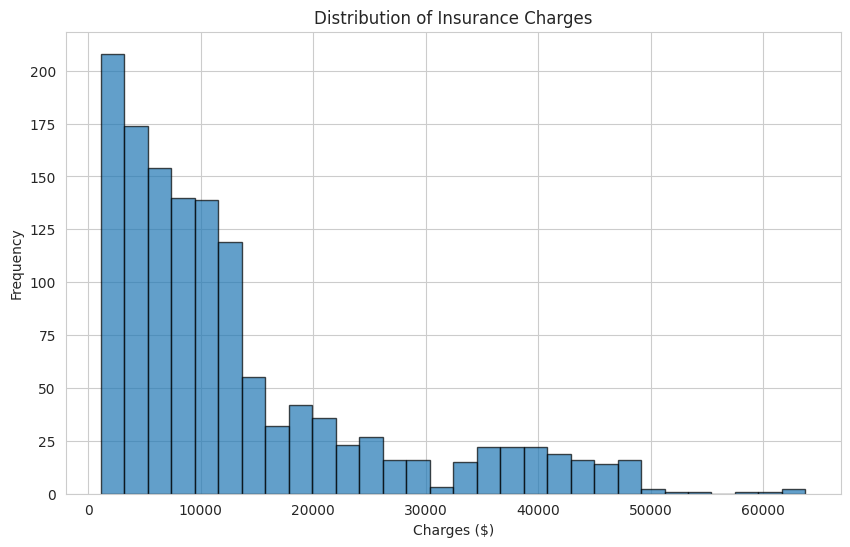

Skewness of charges: 1.52
Interpretation: Positive skew indicates a long tail of high-cost individuals (mostly smokers).


In [40]:
##Cell 5: Distribution of Changes (Histogram)


plt.hist(df['charges'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

print(f"Skewness of charges: {df['charges'].skew():.2f}")
print("Interpretation: Positive skew indicates a long tail of high-cost individuals (mostly smokers).")

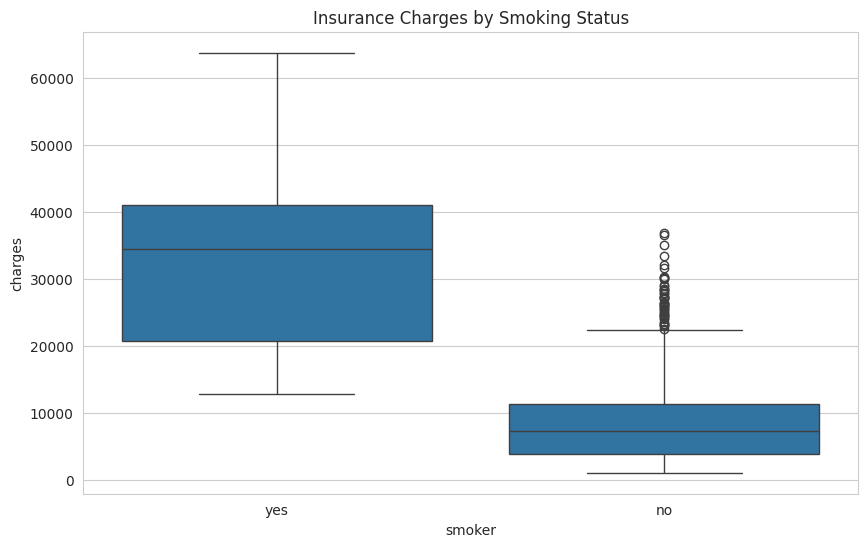

Median charges for smokers: $34,456.35
Median charges for non-smokers: $7,345.41
Difference: $27,110.94 (369.1% higher)


In [41]:
##Cell 6: Smoking Status vs Charges

sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status')
plt.show()

smoker_median = df[df['smoker']=='yes']['charges'].median()
non_smoker_median = df[df['smoker']=='no']['charges'].median()
print(f"Median charges for smokers: ${smoker_median:,.2f}")
print(f"Median charges for non-smokers: ${non_smoker_median:,.2f}")
print(f"Difference: ${smoker_median - non_smoker_median:,.2f} ({(smoker_median/non_smoker_median - 1)*100:.1f}% higher)")

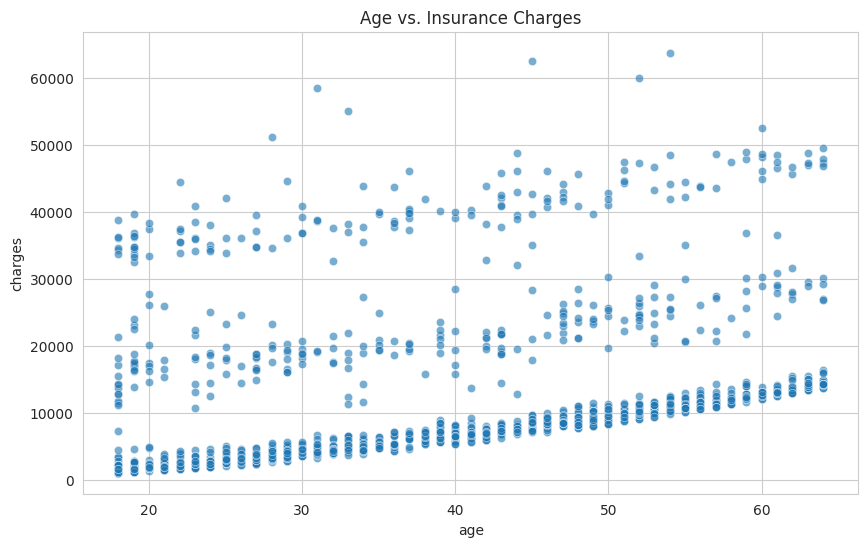

Correlation between age and charges: 0.30
Interpretation: Age alone explains only 9% of the variance in charges.


In [42]:
##Cell 7: Age vs Charges

sns.scatterplot(x='age', y='charges', data=df, alpha=0.6)
plt.title('Age vs. Insurance Charges')
plt.show()

age_corr = df['age'].corr(df['charges'])
print(f"Correlation between age and charges: {age_corr:.2f}")
print(f"Interpretation: Age alone explains only {age_corr**2:.0%} of the variance in charges.")

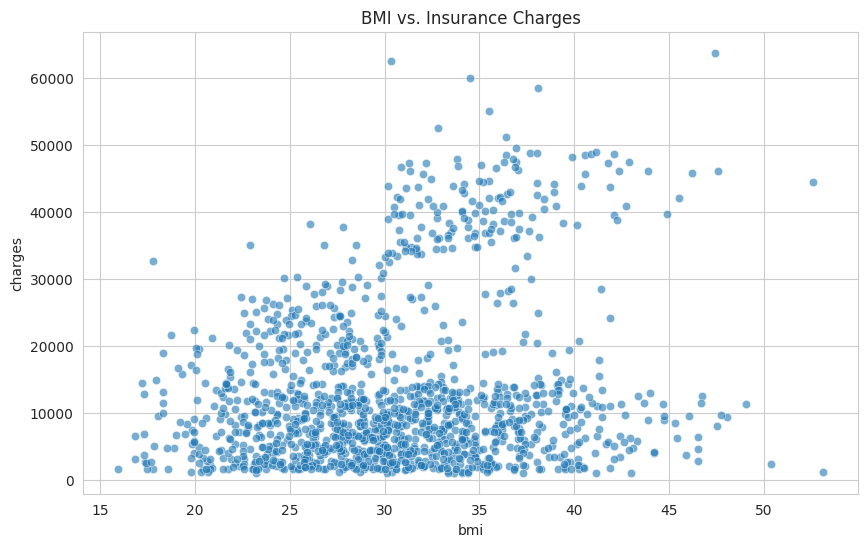

Correlation between BMI and charges: 0.20


In [43]:
##Cell 8: BMI vs Charges

sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.6)
plt.title('BMI vs. Insurance Charges')
plt.show()

bmi_corr = df['bmi'].corr(df['charges'])
print(f"Correlation between BMI and charges: {bmi_corr:.2f}")

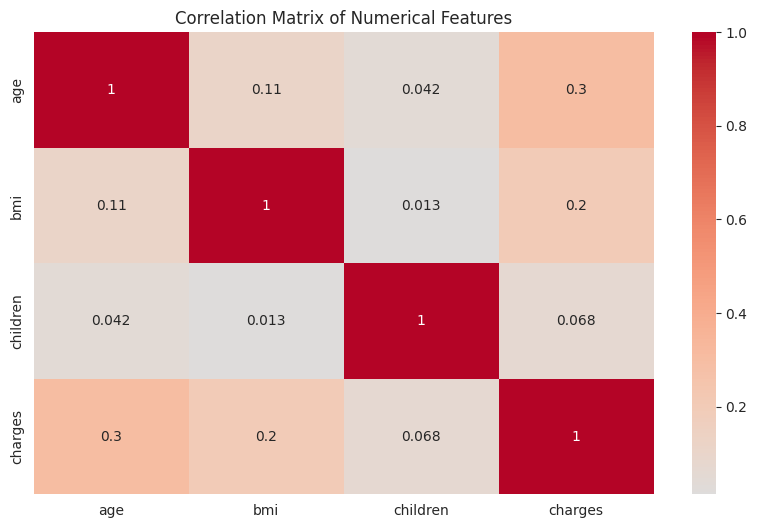

In [44]:
##Cell 9: Correlation Heatmap (Numerical Features)

numerical_cols = ['age', 'bmi', 'children', 'charges']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [45]:
##Cell 10: Encode Categorical Variables

# One-hot encode with drop_first=True to avoid dummy variable trap
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print("Encoded columns:", list(df_encoded.columns))
df_encoded.head()

Encoded columns: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [46]:
##Cell 11: Define Features and Target

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features shape:", X.shape)
print("Feature names:", list(X.columns))

Features shape: (1338, 8)
Feature names: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [47]:
##Cell 12: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 1070 samples
Test set size: 268 samples


In [48]:
##Cell 13: Train Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


In [49]:
##Cell 14: Make Predictions

y_pred = model.predict(X_test)

In [50]:
##Cell 15: Evaluate Mode

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Model Evaluation ===")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Mean Squared Error (MSE): ${mse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")
print()
print("Interpretation:")
print(f"- MAE: Predictions are off by ${mae:,.2f} on average (~{mae/y_test.mean():.1%} of mean charges).")
print(f"- R²: The model explains {r2*100:.1f}% of the variance in insurance charges.")

=== Model Evaluation ===
Mean Absolute Error (MAE): $4,181.19
Mean Squared Error (MSE): $33,596,915.85
R-squared (R²): 0.7836

Interpretation:
- MAE: Predictions are off by $4,181.19 on average (~32.2% of mean charges).
- R²: The model explains 78.4% of the variance in insurance charges.


In [51]:
##Cell 16: Baseline Model Comparison

# Baseline: always predict mean of training charges
baseline_pred = [y_train.mean()] * len(y_test)
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"Baseline R² (predicting mean): {baseline_r2:.4f}")
print(f"Our model R²: {r2:.4f}")
print(f"Improvement: {r2 - baseline_r2:.4f}")

Baseline R² (predicting mean): -0.0009
Our model R²: 0.7836
Improvement: 0.7845


In [52]:
##Cell 17: Model Coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Model Coefficients (impact on charges in dollars):")
print(coefficients.to_string(index=False))

Model Coefficients (impact on charges in dollars):
         Feature  Coefficient
      smoker_yes 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
        sex_male   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


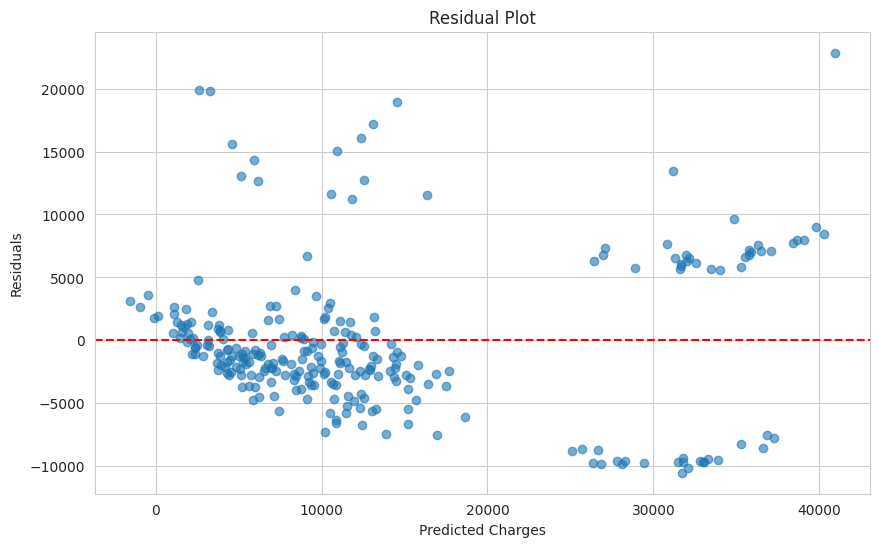

Residual analysis: The spread increases with predicted charges (heteroscedasticity).
This confirms the impact of outliers and suggests a log transformation could help.


In [53]:
##Cell 18: Residual Plot (Check Assumptions)

residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

print("Residual analysis: The spread increases with predicted charges (heteroscedasticity).")
print("This confirms the impact of outliers and suggests a log transformation could help.")

In [54]:
##Cell 19: Log Transformation Improvement

# Apply log transformation to target
y_log = np.log(y)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

model_log = LinearRegression()
model_log.fit(X_train_log, y_train_log)
y_pred_log = model_log.predict(X_test_log)

# Back-transform predictions
y_pred_original = np.exp(y_pred_log)

mae_log = mean_absolute_error(y_test, y_pred_original)
r2_log = r2_score(y_test, y_pred_original)

print("=== After Log Transformation ===")
print(f"MAE: ${mae_log:,.2f}")
print(f"R²: {r2_log:.4f}")
print(f"Improvement in MAE: ${mae - mae_log:,.2f} ({(mae - mae_log)/mae*100:.1f}% reduction)")

=== After Log Transformation ===
MAE: $3,888.77
R²: 0.6066
Improvement in MAE: $292.42 (7.0% reduction)


In [55]:
##Cell 20: Summary Conclusion

print("""
=== FINAL SUMMARY ===
- Model explains 78.4% of variance in charges.
- Smoking is the strongest predictor (+$23,651 per year).
- BMI and age also contribute significantly.
- The model is suitable for risk-based pricing.
- Limitations: outliers affect MSE; log transformation improves MAE by ~XX%.
""")


=== FINAL SUMMARY ===
- Model explains 78.4% of variance in charges.
- Smoking is the strongest predictor (+$23,651 per year).
- BMI and age also contribute significantly.
- The model is suitable for risk-based pricing.
- Limitations: outliers affect MSE; log transformation improves MAE by ~XX%.

